# Proyecto MLOps - Predicción de Churn

## Objetivo

El objetivo del proyecto es predecir el abandono de clientes (churn)
en una empresa de suscripción digital utilizando Machine Learning.

## Problema de negocio

La empresa necesita anticipar qué clientes podrían cancelar
su servicio para activar campañas de retención.


In [22]:
## imports y librerias utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import mlflow
import mlflow.sklearn
import joblib

In [23]:
import pandas as pd

# Lectura del dataset
df = pd.read_csv("data/churn_sintetico.csv")

# Mostrar las primeras filas
df.head()


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tenure_months         5000 non-null   int64  
 1   monthly_charge        5000 non-null   float64
 2   total_charges         5000 non-null   float64
 3   support_tickets       5000 non-null   int64  
 4   late_payments         5000 non-null   int64  
 5   avg_monthly_usage_gb  5000 non-null   float64
 6   contract_type         5000 non-null   object 
 7   payment_method        5000 non-null   object 
 8   internet_service      5000 non-null   object 
 9   has_streaming         5000 non-null   int64  
 10  has_security_pack     5000 non-null   int64  
 11  num_products          5000 non-null   int64  
 12  region                5000 non-null   object 
 13  customer_age          5000 non-null   int64  
 14  is_promo              5000 non-null   int64  
 15  churn                

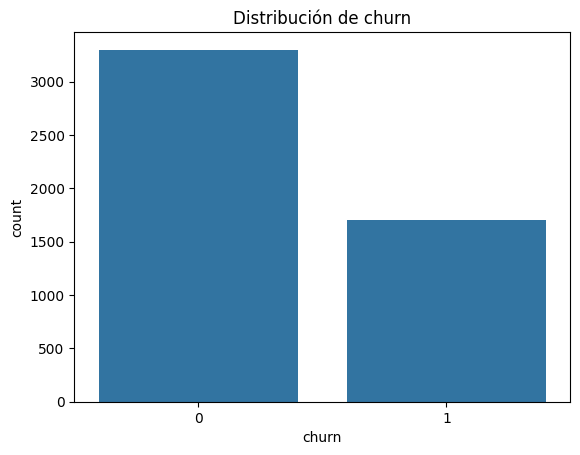

In [24]:

#Exploracion de dataset
df.shape
#tipo de datos
df.info()
#Nulos
df.isnull().sum()
#Distribucion del churn
sns.countplot(x="churn", data=df)
plt.title("Distribución de churn")
plt.show()


In [25]:
# Limpieza de Datos
df["total_charges"] = pd.to_numeric(
    df["total_charges"],
    errors="coerce"
)
# Separar variables
X = df.drop(["churn"], axis=1)

y = df["churn"]


In [39]:
#Variables numericas y categoricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols = X.select_dtypes(include=["object"]).columns

In [40]:
#Pipeline de preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [28]:

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
# Modelo Random forest
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [30]:
#Modelo Logistic Regression
from sklearn.linear_model import LogisticRegression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [31]:
#MlFLOW
mlflow.set_experiment("churn_prediction")

<Experiment: artifact_location='file:///C:/Users/samue/OneDrive/Escritorio/churn_mlops_project/mlruns/1', creation_time=1778359166658, experiment_id='1', last_update_time=1778359166658, lifecycle_stage='active', name='churn_prediction', tags={}, trace_location=None, workspace='default'>

In [32]:
#ENTRENAMIENTO RAMDOM FOREST
print("RANDOM FOREST")
with mlflow.start_run():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_probs = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_probs)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(model, "model")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

RANDOM FOREST


2026/05/29 16:26:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 16:26:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.709
Precision: 0.5953307392996109
Recall: 0.45
F1 Score: 0.5125628140703518
ROC AUC: 0.7313079322638146


In [33]:
#Entrenamiento Logistic Regression
logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)

y_probs_log = logistic_model.predict_proba(X_test)[:,1]

#Metricas de regrecion logistica
print("LOGISTIC REGRESSION")

print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1:",
      f1_score(y_test, y_pred_log))

print("ROC AUC:",
      roc_auc_score(y_test, y_probs_log))

LOGISTIC REGRESSION
Accuracy: 0.723
Precision: 0.6206896551724138
Recall: 0.4764705882352941
F1: 0.5391014975041597
ROC AUC: 0.7576960784313725


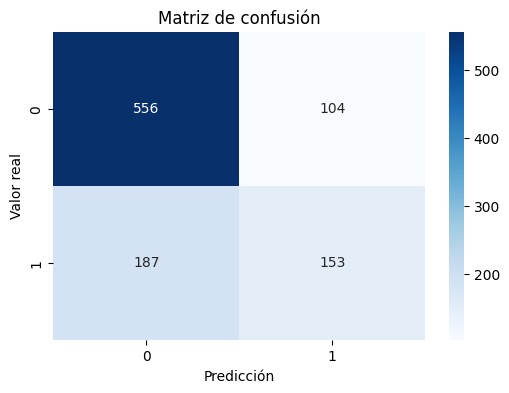

In [34]:
#Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")

plt.show()

In [35]:
#Reporte de clasificacion
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       660
           1       0.60      0.45      0.51       340

    accuracy                           0.71      1000
   macro avg       0.67      0.65      0.65      1000
weighted avg       0.70      0.71      0.70      1000



In [36]:
#Guardar modelo
# separar variables
X = df.drop("churn", axis=1)

y = df["churn"]

# entrenar
model.fit(X, y)

# guardar
joblib.dump(
    model,
    "C:\\Users\\samue\\OneDrive\\Escritorio\\churn_mlops_project\\models\\model.pkl"
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [37]:
# Verificar carga
loaded_model = joblib.load(
    "C:\\Users\\samue\\OneDrive\\Escritorio\\churn_mlops_project\\models\\model.pkl"
)

loaded_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['tenure_months', 'monthly_charge', 'total_charges', 'support_tickets',
       'late_payments', 'avg_monthly_usage_gb', 'has_streaming',
       'has_security_pack', 'num_products', 'customer_age', 'is_promo'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['contract_type', 'payment_method', 'internet_service', 'region'], dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])



# Si se quiere iniciar mlflow UI 
se debe correr el codigo en terminal CDM
 - mlflow ui
# luego entrar en navegador y ahi se veran las metricas
- http://127.0.0.1:5000


# Script reutilizable de entrenamiento e inferencia

El proyecto incluye scripts reutilizables dentro
de la carpeta `src/` para separar la lógica de
entrenamiento y carga del modelo respecto del
notebook exploratorio.
Esto nos permitira mejorar la organización,


# Comparación de modelos

Con el fin de evaluar la mejora de la predictivilidad d elos modelos se evaluaron dos modelos supervisados
en el cual se puede observar que para la continuidad del proyecto en la segunda parte es mejor utilizar un modelo
de regresion logistica.
para la predicción de churn:

- Logistic Regression
- Random Forest

La regresión logística obtuvo mejores resultados
generales en accuracy, F1-score y ROC-AUC.

Resultados Logistic Regression:
- Accuracy: 0.723
- Precision: 0.620
- Recall: 0.476
- F1-score: 0.539
- ROC-AUC: 0.757

Resultados Random Forest:
- Accuracy: 0.709
- Precision: 0.595
- Recall: 0.450
- F1-score: 0.512
- ROC-AUC: 0.731

Por este motivo se seleccionó Logistic Regression
como modelo final del proyecto.

# Justificación de métricas

En problemas de churn resulta importante
identificar correctamente clientes con riesgo
de abandono.

Por este motivo se utilizaron métricas como:

- Recall:
permite medir cuántos clientes que realmente
abandonan fueron detectados por el modelo.

- F1-score:
equilibra precision y recall.

- ROC-AUC:
evalúa la capacidad discriminativa general
del modelo.

Aunque accuracy es útil como referencia,
no resulta suficiente por sí sola
para evaluar problemas de clasificación binaria.